### Principal components analysis (PCA)


In [7]:
import sys
from pathlib import Path


project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root))

import pandas as pd

from src.config.config import PathsConfig

from src.database.connections import get_motherduck_connection
from src.database.readers.bank_reader import BankDBReader

cleaned_data_path = PathsConfig.CLEAN_DATA_PATH

cleaned_data_path

df = pd.read_csv(cleaned_data_path)
df

,customer_id,date_of_birth,country,segment,credit_score,income_usd,occupation,education_level,customer_status,Cuenta Ahorro,...,Inversión,Préstamo Hipotecario,Préstamo Personal,Seguro,Tarjeta Crédito,Tarjeta Débito,num_products,Deuda_usd,Activos_financieros_usd,Edad
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,7329.494286,Administrative,University,Active,0.00,...,0.00,0.0,0.00,0.0,1789.106999,0.000000,2,1789.106999,4806.458992,59
1,CLI-8WU28O74XKHS,1995-02-09,México,Basic,657.0,1567.247000,Teacher,NaN,Active,6702.06,...,0.00,0.0,0.00,0.0,1058.870000,0.000000,2,1058.870000,6702.060000,31
2,CLI-C4Z5FPK4YO51,1985-07-22,México,Basic,594.0,1389.186150,Lawyer,Elementary,Active,500.61,...,1948.10,0.0,0.00,0.0,2345.510000,0.000000,4,2345.510000,5508.660000,41
3,CLI-5OWUVS7SPGKX,1944-04-11,México,Basic,604.0,793.675300,Lawyer,College Prep,Active,11157.03,...,0.00,0.0,0.00,0.0,4859.160000,0.000000,3,4859.160000,13624.670000,82
4,CLI-WUJQSWH9HDOS,1992-05-23,México,Plus,726.0,8645.649100,Retired,Graduate,Active,3866.15,...,20454.85,0.0,0.00,0.0,5196.390000,0.000000,4,5196.390000,26365.820000,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72375,CLI-9M0OBOMBQJ9C,1965-12-06,Colombia,Plus,741.0,8375.846480,Employee,University,Active,0.00,...,0.00,0.0,0.00,0.0,2210.946108,0.000000,1,2210.946108,0.000000,61
72376,CLI-V2TFDD8DNAJD,2004-11-06,Colombia,Plus,733.0,7204.326790,Independent Professional,High School,Active,0.00,...,0.00,0.0,0.00,0.0,3369.717379,0.000000,2,3369.717379,2243.235978,22
72377,CLI-7JYUMA4CBEGO,1963-07-02,Colombia,Basic,605.0,2116.709555,Doctor,NaN,Active,0.00,...,0.00,0.0,9002.69,0.0,0.000000,0.000000,1,9002.690000,0.000000,63
72378,CLI-RIC89ZT9MIIZ,1992-12-22,Colombia,Plus,666.0,6759.875099,Consultant,Graduate,Active,0.00,...,0.00,0.0,0.00,0.0,0.000000,1376.924293,1,0.000000,1376.924293,34


In [8]:
numerical_columns = [
    "Edad"
]

log_columns = [
    "credit_score",
    "income_usd",
    "Deuda_usd",
    "Activos_financieros_usd"
]

categorical_columns = [
    "country",
    "education_level"
]

from src.preprocessing.pipelines import CustomerPreprocessor

preprocessor = CustomerPreprocessor(
    log_columns=log_columns,
    numerical_columns= numerical_columns,
    categorical_columns=categorical_columns
)



In [9]:
X = preprocessor.fit_transform(df)

print("Shape de X:", X.shape)

feature_names = preprocessor.get_feature_names()

for i, feature in enumerate(feature_names):
    print(i, feature)

Shape de X: (72380, 14)
0 log_numeric__credit_score
1 log_numeric__income_usd
2 log_numeric__Deuda_usd
3 log_numeric__Activos_financieros_usd
4 numeric__Edad
5 categorical__country_Argentina
6 categorical__country_Colombia
7 categorical__country_México
8 categorical__education_level_College Prep
9 categorical__education_level_Elementary
10 categorical__education_level_Graduate
11 categorical__education_level_High School
12 categorical__education_level_University
13 categorical__education_level_nan


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=6)

pca.fit(X)

proyeccion = pca.transform(X)

proyeccion = pca.fit_transform(X)

pca = PCA(n_components=6)

proyeccion = pca.fit_transform(X)

print(pca.explained_variance_ratio_)

KeyboardInterrupt: 

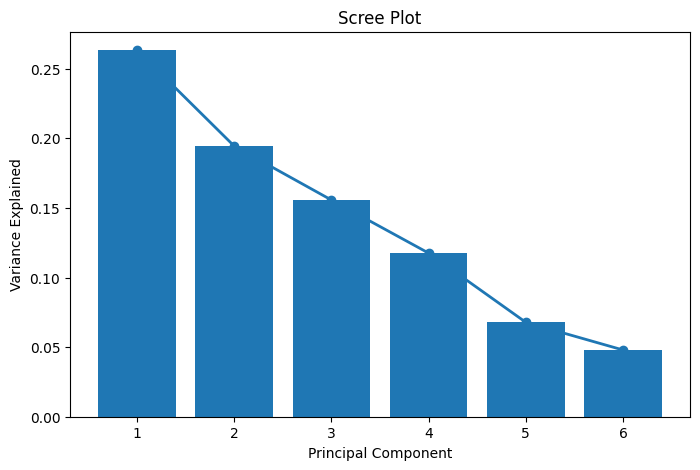

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

PC_values = np.arange(1, pca.n_components_ + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    PC_values,
    pca.explained_variance_ratio_,
    "o-",
    linewidth=2
)

plt.bar(
    PC_values,
    pca.explained_variance_ratio_
)

plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.xticks(PC_values)

plt.show()

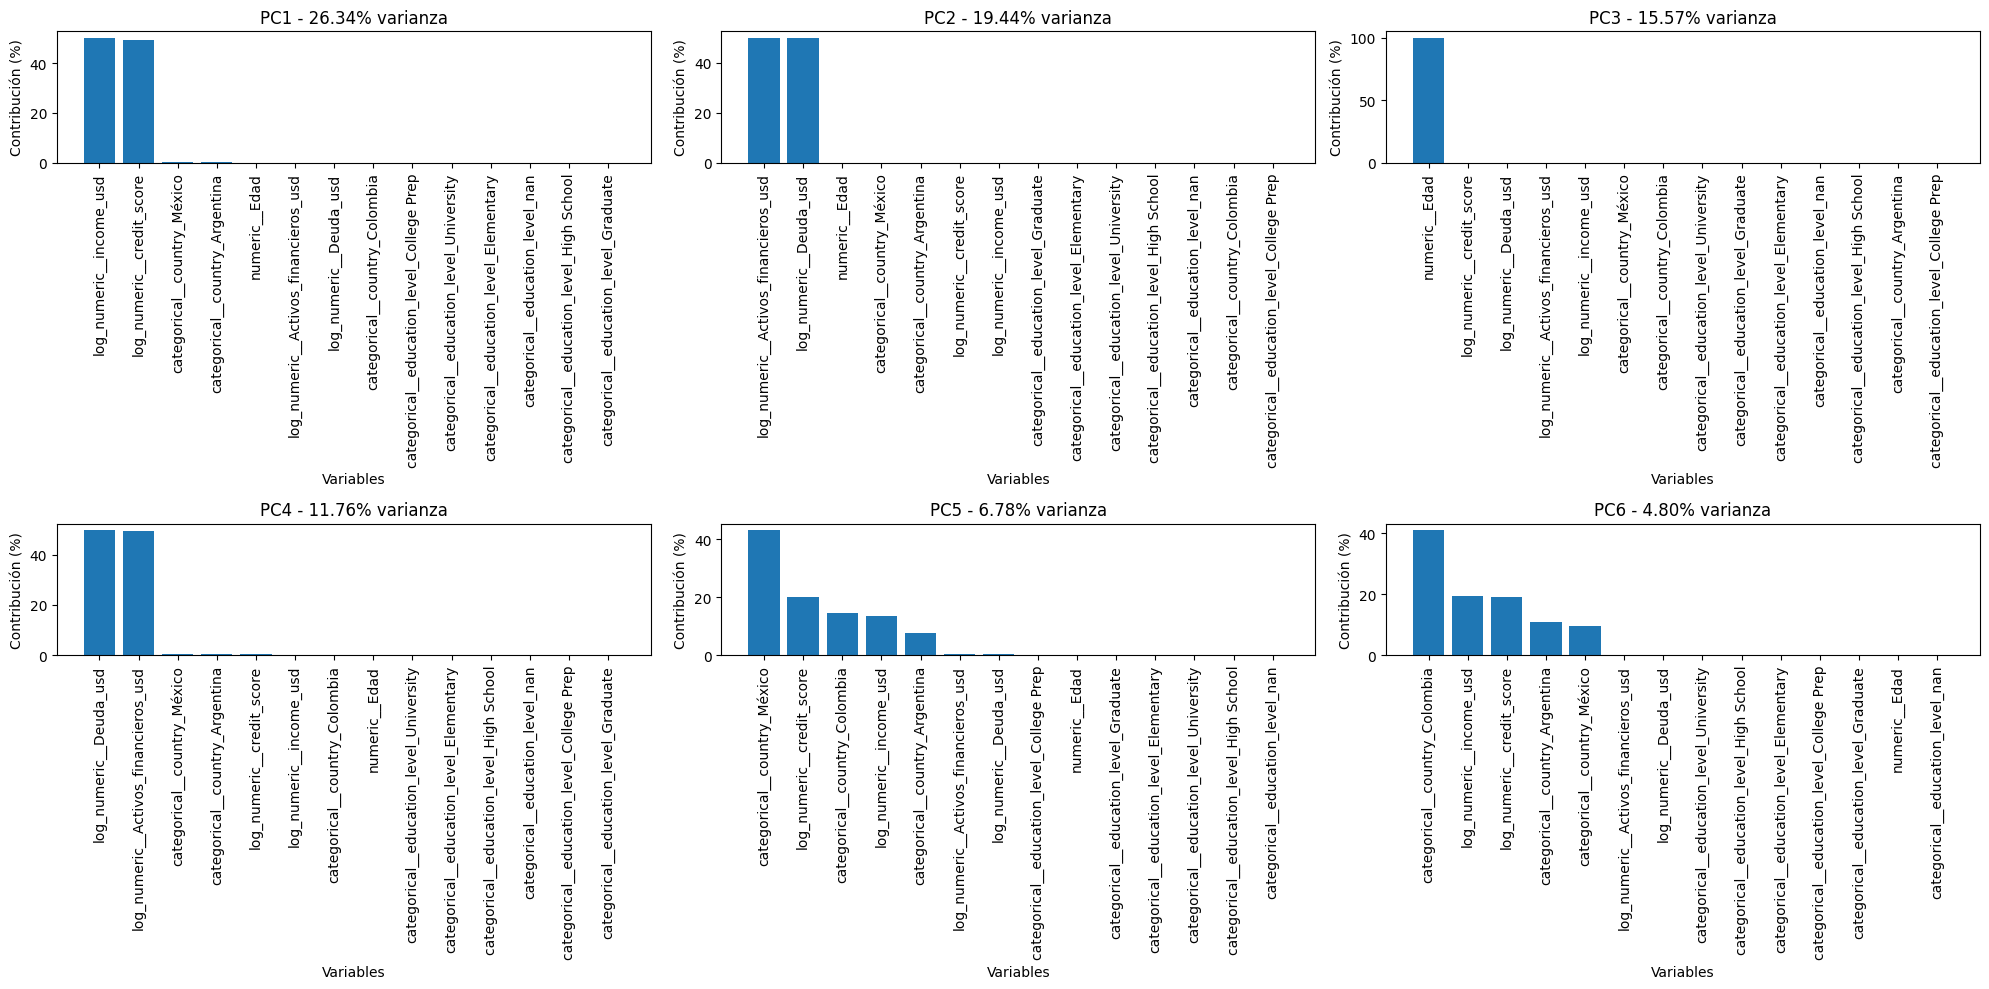

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

variables = preprocessor.get_feature_names()

# Loadings:
# filas    -> variables
# columnas -> componentes
loadings = pca.components_.T

# Número de componentes
n_components = pca.n_components_

# Crear figura con 2 filas x 3 columnas
fig, axes = plt.subplots(
    2, 3,
    figsize=(20, 10)
)

axes = axes.flatten()

for i in range(n_components):

    # Loading del componente i
    component_loadings = loadings[:, i]

    # Contribución porcentual
    contributions = (
        component_loadings ** 2
        / np.sum(component_loadings ** 2)
    ) * 100

    # Ordenar de mayor a menor
    order = np.argsort(contributions)[::-1]

    sorted_variables = np.array(variables)[order]
    sorted_contributions = contributions[order]

    # Gráfico
    axes[i].bar(
        sorted_variables,
        sorted_contributions
    )

    axes[i].set_title(
        f"PC{i + 1} - {pca.explained_variance_ratio_[i] * 100:.2f}% varianza"
    )

    axes[i].set_xlabel("Variables")
    axes[i].set_ylabel("Contribución (%)")

    axes[i].tick_params(
        axis="x",
        rotation=90
    )

plt.tight_layout()
plt.show()

In [7]:
contributions_matrix = []

for i in range(n_components):

    component_loadings = loadings[:, i]

    contributions = (
        component_loadings ** 2
        / np.sum(component_loadings ** 2)
    ) * 100

    contributions_matrix.append(contributions)

contributions_matrix = np.array(contributions_matrix).T

contributions_df = pd.DataFrame(
    contributions_matrix,
    index=variables,
    columns=[f"PC{i + 1}" for i in range(n_components)]
)

print(contributions_df)

                                                 PC1        PC2           PC3  \
log_numeric__credit_score                  49.120804   0.003317  2.246660e-02   
log_numeric__income_usd                    50.268384   0.000461  4.620980e-03   
log_numeric__Deuda_usd                      0.009912  49.856637  2.072578e-02   
log_numeric__Activos_financieros_usd        0.014838  50.088958  6.612042e-03   
numeric__Edad                               0.022924   0.025729  9.994178e+01   
categorical__country_Argentina              0.240664   0.011715  3.886324e-06   
categorical__country_Colombia               0.005067   0.000017  1.101740e-03   
categorical__country_México                 0.315572   0.012631  1.236496e-03   
categorical__education_level_College Prep   0.001445   0.000011  4.587254e-07   
categorical__education_level_Elementary     0.000149   0.000150  4.219749e-05   
categorical__education_level_Graduate       0.000002   0.000196  5.177747e-04   
categorical__education_level

In [ ]:
rows = []

for i in range(pca.n_components_):

    pc = f"PC{i + 1}"

    loadings_pc = pca.components_[i]

    contributions = (
        loadings_pc ** 2
        / np.sum(loadings_pc ** 2)
    ) * 100

    for variable, loading, contribution in zip(
        variables,
        loadings_pc,
        contributions
    ):
        rows.append({
            "component": pc,
            "variable": variable,
            "loading": loading,
            "abs_loading": abs(loading),
            "contribution_%": contribution
        })

pca_loadings_df = pd.DataFrame(rows)

for pc in pca_loadings_df["component"].unique():

    print(f"\n{'=' * 60}")
    print(pc)

    print(
        pca_loadings_df[
            pca_loadings_df["component"] == pc
        ]
        .sort_values("contribution_%", ascending=False)
        .head(5)
    )


PC1
  component                        variable   loading  abs_loading  \
1       PC1         log_numeric__income_usd  0.709002     0.709002   
0       PC1       log_numeric__credit_score  0.700862     0.700862   
7       PC1     categorical__country_México -0.056176     0.056176   
5       PC1  categorical__country_Argentina  0.049058     0.049058   
4       PC1                   numeric__Edad -0.015141     0.015141   

   contribution_%  
1       50.268384  
0       49.120804  
7        0.315572  
5        0.240664  
4        0.022924  

PC2
   component                              variable   loading  abs_loading  \
17       PC2  log_numeric__Activos_financieros_usd -0.707736     0.707736   
16       PC2                log_numeric__Deuda_usd  0.706092     0.706092   
18       PC2                         numeric__Edad -0.016040     0.016040   
21       PC2           categorical__country_México  0.011239     0.011239   
19       PC2        categorical__country_Argentina -0.010824    

In [ ]:
for i in range(pca.n_components_):
    df[f"pca_{i + 1}"] = proyeccion[:, i]


df[
    [
        "customer_id",
        "segment",
        "pca_1",
        "pca_2",
        "pca_3",
        "pca_4",
        "pca_5",
        "pca_6"
    ]
].head()

,customer_id,segment,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6
0,CLI-G4X2AMVD62NR,Plus,1.146602,0.198479,0.379630,-0.536175,0.467888,0.635012
1,CLI-8WU28O74XKHS,Basic,-0.412965,0.065713,-1.182482,-0.460729,-0.923631,0.149806
2,CLI-C4Z5FPK4YO51,Basic,-1.118814,0.231277,-0.641960,-0.585388,-0.581606,-0.167506
3,CLI-5OWUVS7SPGKX,Basic,-1.450510,0.100270,1.617252,-0.897350,-0.860197,0.148204
4,CLI-WUJQSWH9HDOS,Plus,1.447732,-0.000247,-0.992348,-1.045543,-0.712551,-0.230382


In [ ]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="pca_1",
    y="pca_2",
    z="pca_3",
    color="segment",
    opacity=0.5,
    title="Clientes en el espacio PCA"
)

fig.update_traces(marker=dict(size=3))

fig.update_layout(
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3"
    ),
    width=1000,
    height=800
)

fig.show()

c:\Users\Administrador\AppData\Local\Programs\Python\Python310\lib\site-packages\plotly\express\_core.py:1980: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  sf: grouped.get_group(s if len(s) > 1 else s[0])


## Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca_columns = [f"pca_{i}" for i in range(1, 7)]

X_cluster = df[pca_columns]

X_cluster.head()



,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6
0,1.146602,0.198479,0.379630,-0.536175,0.467888,0.635012
1,-0.412965,0.065713,-1.182482,-0.460729,-0.923631,0.149806
2,-1.118814,0.231277,-0.641960,-0.585388,-0.581606,-0.167506
3,-1.450510,0.100270,1.617252,-0.897350,-0.860197,0.148204
4,1.447732,-0.000247,-0.992348,-1.045543,-0.712551,-0.230382


In [12]:
import numpy as np

k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_cluster)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_cluster, labels)
    )

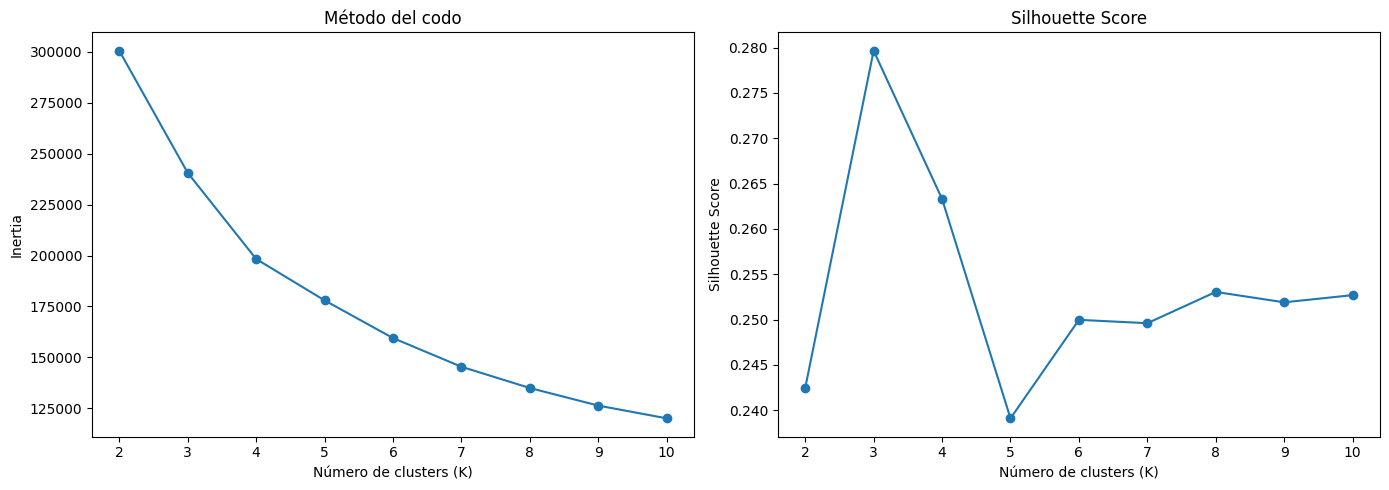

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(k_values, inertias, marker="o")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Método del codo")

# Silhouette
axes[1].plot(k_values, silhouette_scores, marker="o")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score")

plt.tight_layout()
plt.show()

In [14]:
clustering_evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouette_scores
})


clustering_evaluation.sort_values(
    "Silhouette",
    ascending=False
)
print(clustering_evaluation)


    K        Inertia  Silhouette
0   2  300514.041223    0.242453
1   3  240590.539729    0.279650
2   4  198311.763956    0.263299
3   5  177991.995790    0.239102
4   6  159495.685454    0.249967
5   7  145413.958348    0.249596
6   8  134976.890759    0.253045
7   9  126356.022506    0.251900
8  10  120096.015366    0.252690


In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_cluster)



In [16]:
df["cluster"].value_counts().sort_index()

cluster
0     8205
1    42617
2    21558
Name: count, dtype: int64

In [ ]:
cluster_profile = df.groupby("cluster").agg(
    clientes=("customer_id", "count"),
    
    edad_media=("Edad", "mean"),
    edad_mediana=("Edad", "median"),
    
    credit_score_medio=("credit_score", "mean"),
    credit_score_mediano=("credit_score", "median"),
    
    ingreso_medio=("income_usd", "mean"),
    ingreso_mediano=("income_usd", "median"),
    
    deuda_media=("Deuda_usd", "mean"),
    deuda_mediana=("Deuda_usd", "median"),
    
    activos_medios=("Activos_financieros_usd", "mean"),
    activos_medianos=("Activos_financieros_usd", "median")
)

cluster_profile.round(2)

cluster_profile["porcentaje_clientes"] = (
    cluster_profile["clientes"]
    / len(df)
    * 100
)

cluster_profile.round(2)


print(cluster_profile)

         clientes  edad_media  edad_mediana  credit_score_medio  \
cluster                                                           
0            8205   52.298233          52.0          646.838635   
1           42617   52.630758          53.0          603.532745   
2           21558   52.303739          52.0          731.844373   

         credit_score_mediano  ingreso_medio  ingreso_mediano   deuda_media  \
cluster                                                                       
0                       632.0    5482.123002      2562.804535  17396.538804   
1                       603.0    2095.959064      1937.526250  10043.034376   
2                       723.0   12185.960022      9280.378556  10518.240170   

         deuda_mediana  activos_medios  activos_medianos  porcentaje_clientes  
cluster                                                                        
0             3085.910        0.406216          0.000000            11.336004  
1             1202.290     9

In [ ]:
segment_distribution = pd.crosstab(
    df["cluster"],
    df["segment"],
    normalize="index"
).mul(100).round(2)

print(segment_distribution)

segment  Basic   Plus  Premium  Student
cluster                                
0        60.22  24.78    10.14     4.86
1        89.59   2.90     0.00     7.51
2         1.79  68.07    30.10     0.04


In [ ]:
df

,customer_id,date_of_birth,country,segment,credit_score,income_usd,occupation,education_level,customer_status,Cuenta Ahorro,...,Deuda_usd,Activos_financieros_usd,Edad,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,cluster
0,CLI-G4X2AMVD62NR,1967-06-18,Colombia,Plus,701.0,7329.494286,Administrative,University,Active,0.00,...,1789.106999,4806.458992,59,1.146602,0.198479,0.379630,-0.536175,0.467888,0.635012,2
1,CLI-8WU28O74XKHS,1995-02-09,México,Basic,657.0,1567.247000,Teacher,NaN,Active,6702.06,...,1058.870000,6702.060000,31,-0.412965,0.065713,-1.182482,-0.460729,-0.923631,0.149806,1
2,CLI-C4Z5FPK4YO51,1985-07-22,México,Basic,594.0,1389.186150,Lawyer,Elementary,Active,500.61,...,2345.510000,5508.660000,41,-1.118814,0.231277,-0.641960,-0.585388,-0.581606,-0.167506,1
3,CLI-5OWUVS7SPGKX,1944-04-11,México,Basic,604.0,793.675300,Lawyer,College Prep,Active,11157.03,...,4859.160000,13624.670000,82,-1.450510,0.100270,1.617252,-0.897350,-0.860197,0.148204,1
4,CLI-WUJQSWH9HDOS,1992-05-23,México,Plus,726.0,8645.649100,Retired,Graduate,Active,3866.15,...,5196.390000,26365.820000,34,1.447732,-0.000247,-0.992348,-1.045543,-0.712551,-0.230382,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72375,CLI-9M0OBOMBQJ9C,1965-12-06,Colombia,Plus,741.0,8375.846480,Employee,University,Active,0.00,...,2210.946108,0.000000,61,1.543618,2.286074,0.522300,1.485381,0.513299,0.722509,0
72376,CLI-V2TFDD8DNAJD,2004-11-06,Colombia,Plus,733.0,7204.326790,Independent Professional,High School,Active,0.00,...,3369.717379,2243.235978,22,1.434329,0.521637,-1.652629,-0.443356,0.288754,0.826419,2
72377,CLI-7JYUMA4CBEGO,1963-07-02,Colombia,Basic,605.0,2116.709555,Doctor,NaN,Active,0.00,...,9002.690000,0.000000,63,-0.687421,2.509774,0.598019,1.191631,0.756844,0.600081,0
72378,CLI-RIC89ZT9MIIZ,1992-12-22,Colombia,Plus,666.0,6759.875099,Consultant,Graduate,Active,0.00,...,0.000000,1376.924293,34,0.776555,-0.727968,-1.032956,0.986997,0.748321,0.454245,2


c:\Users\Administrador\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

c:\Users\Administrador\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



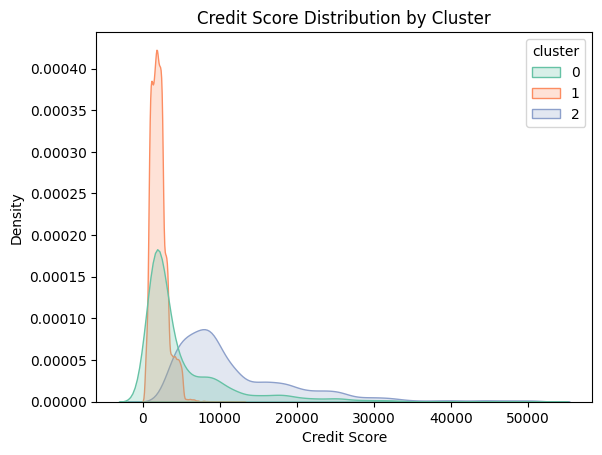

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(
    data=df,
    x="income_usd",
    hue="cluster",
    fill=True,
    common_norm=False,
    palette= sns.color_palette("Set2", n_colors=df["cluster"].nunique())
)

plt.title("Credit Score Distribution by Cluster")
plt.xlabel("Credit Score")
plt.ylabel("Density")
plt.show()

### Añadir información transaccional 

In [11]:
from src.preprocessing.pipelines import TransactionBehaviorPipeline

con = get_motherduck_connection("latam_bank")

reader = BankDBReader(con)

transacciones = reader.consulta_transacciones_batches(customer_ids= ["CLI-AXQNPFTCRJ8P","CLI-8WU28O74XKHS"] ,batch_size=10000,limit=1000)

con.close()

print(transacciones.head())

transaction_pipeline = TransactionBehaviorPipeline()

transaction_behavior = (
    transaction_pipeline
    .fit_transform(transacciones)
)
transaction_behavior

C:\Users\Administrador\Desktop\Hackaton\src\database\readers\bank_reader.py:251: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(


Procesados 2 de 2 clientes
             transaction_id    transaction_date process_date  \
0  TRX-STH7VB090PK2NQTQVEKB 2023-06-17 06:01:30   2023-06-17   
1  TRX-BF2JARQH8MB8XTTTZAC6 2023-06-25 00:16:03   2023-06-24   
2  TRX-ASL466MOUOT357ZBX5V7 2023-07-05 01:16:02   2023-07-04   
3  TRX-JGE6AMIKJQ8LCDE77CG8 2023-08-05 02:09:50   2023-08-04   
4  TRX-9LLQC05O1S10XI1YZ89I 2023-08-05 08:33:49   2023-08-05   

         product_id       customer_id transaction_type transaction_category  \
0  PRD-ZUDZW1EKXBBU  CLI-AXQNPFTCRJ8P       Withdrawal                 None   
1  PRD-SEFXF1889Y6B  CLI-8WU28O74XKHS          Deposit                 None   
2  PRD-PDCT6HT3ZJQS  CLI-AXQNPFTCRJ8P         Purchase             Services   
3  PRD-YUC1QPDMOMA4  CLI-AXQNPFTCRJ8P          Deposit                 None   
4  PRD-U459TUPWLX6A  CLI-8WU28O74XKHS          Payment            Transport   

    amount currency amount_usd  ... transaction_status response_code is_fraud  \
0   216.56      USD       None  

,customer_id,num_transacciones,num_dias_activos,num_meses_activos,monto_total_usd,monto_promedio_usd,monto_mediano_usd,monto_maximo_usd,monto_p95_usd,monto_std_usd,...,num_ciudades_transaccion,porcentaje_fin_semana,porcentaje_nocturnas,tasa_aprobacion,porcentaje_amount_usd_faltante,transacciones_promedio_mes,transacciones_promedio_mes_activo,transacciones_por_dia_activo,tipo_transaccion_dominante,participacion_tipo_dominante
0,CLI-8WU28O74XKHS,22,22,16,33613.33,1527.878636,564.15,4945.48,4917.6365,1775.649432,...,2,0.181818,0.409091,0.954545,0.0,0.594595,1.375000,1.000000,Purchase,0.454545
1,CLI-AXQNPFTCRJ8P,70,68,31,119949.81,1713.568714,422.22,9898.18,8852.5145,2743.646136,...,7,0.185714,0.385714,0.914286,0.0,1.891892,2.258065,1.029412,Withdrawal,0.271429
